# The Impact of Air Pollution on Asthma: A Regression Analysis

In [5]:
!pip install pandas

In [6]:
!pip install seaborn

In [7]:
!pip install scikit-learn

In [64]:
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


## Goal of the project
This project investigates the relationship between air pollution and asthma in the United States. To achieve this, data from the **US Environmental Protection Agency** (EPA) and the **Centers for Disease Control and Prevention** (CDCs) are combined and analyzed. Air quality indicators are merged with health data at the state and county levels, and exploratory data analysis is conducted to identify patterns. A linear regression model is then applied to examine the relationship between air pollution and asthma prevalence and hospital visits.

## Asthma and air pollution, previous research
According to the Asthma and Allergy Foundation of America, air pollution can cause asthma and other lung diseases. It also worsens asthma symptoms and leads to increased hospital visits. People with asthma are more sensitive to small airborne particles, found in haze, smoke, soot, and airborne dust. Small airborne particles are called “particulate matter” or PM. The smallest particles (PM$_{2.5}$) are the most dangerous. In addition, irritating gases, such as ozone (O$_3$), nitrogen dioxide (NO$_2$), sulfur dioxide (SO$_2$), carbon monoxide (CO), and methane (CH$_4$), can also cause health issues.

The study [Impact of Air Pollution on Asthma Outcomes](https://pmc.ncbi.nlm.nih.gov/articles/PMC7503605/) found that indoor and outdoor pollution represents a major public health threat with a negative impact on asthma outcomes. It demonstrated that not only traffic-related air pollution a risk factor for asthma development in children, but so are NO$_2$ and secondhand smoke exposures. However, **a causal relation between air pollution and the development of adult asthma could not be clearly established**. The exposure to ourdoor pollutants (O$_3$, NO$_2$, SO$_2$, CO, PM) could induce asthma symptoms, exacerbations and hospitalizations.

The study [Associations among air pollution, asthma and lung function](https://www.nature.com/articles/s41598-025-88807-6) found that higher exposure to air pollutants such as PM$_{2.5}$, PM$_{10}$, and NO$_2$ is significantly associated with an increased likelihood of asthma in adults. It also showed that air pollution is linked to worse asthma outcomes, including more frequent wheezing and higher rates of hospitalization. The study concluded that air pollution is an important risk factor for both the occurrence and severity of asthma, although **causal relationships require further longitudinal cohort research**.

The study [Predicting Asthma Hospitalizations from Climate and Air Pollution Data](https://www.mdpi.com/2225-1154/13/2/23#B2-climate-13-00023) found that asthma hospitalizations can be predicted using a combination of air pollution and meteorological variables. Among the tested models, random forest performed best, particularly when past asthma data were included. Key factors influencing asthma hospitalizations include minimum temperature and SO$_2$ levels. The study showed that **combining environmental data with time-series information improves the prediction and monitoring of asthma outcomes**.


## The datasets and preprocessing

#### 1) EPA dataset
EPA measures key air pollutants, including PM$_{2.5}$, O$_3$, NO$_2$, in the US daily. These measurements are converted into the **Air Quality Index (AQI)**. For each day, an AQI value is calculated for each pollutant, and the highest of these values is selected as the overall AQI. This means that the AQI reflects the pollutant posing the greatest health risk on that day, rather than an average of all pollutants. Days are then classified into health categories, and the number of days in each category is counted for each county over the year.


![AQI Scale](images/AQI_scale.jpg)

The dataset also includes data on median AQI, 90th percentile AQI and Max AQI. Median AQI reflects typical air quality conditions, while the 90th-percentile AQI captures frequent high-pollution exposure. Max AQI represents extreme pollution events. The dataset also shows how many days in the year a specific pollutant was the main driver of AQI, which tells us what type of pollution people are exposed to, not just how much.

For our investigation we will work with data for eith years, 2017-2024.

In [9]:
# Loading the datasets
files = glob.glob("data/EPA_annual_aqi_by_county/annual_aqi_by_county_*.csv")
epa_list = [pd.read_csv(file) for file in files]
#Check if all are loaded
len(epa_list)

8

In [10]:
# Combining the datasets
epa = pd.concat(epa_list, ignore_index = True)
epa.shape

(8075, 18)

In [11]:
epa.head()

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,Baldwin,2017,270,224,45,1,0,0,0,108,56,39,0,0,188,82,0
1,Alabama,Clay,2017,118,76,42,0,0,0,0,69,57,40,0,0,0,118,0
2,Alabama,Colbert,2017,283,244,39,0,0,0,0,67,53,39,0,0,202,81,0
3,Alabama,DeKalb,2017,359,305,54,0,0,0,0,80,54,40,0,0,290,69,0
4,Alabama,Elmore,2017,226,221,5,0,0,0,0,58,45,35,0,0,226,0,0


In [12]:
# Checking if we have all years
epa["Year"].value_counts()

Year
2017    1029
2019    1023
2018    1021
2020    1006
2021    1005
2022    1003
2024     996
2023     992
Name: count, dtype: int64

In [13]:
# Checking for missing values
epa.isnull().sum()

State                                  0
County                                 0
Year                                   0
Days with AQI                          0
Good Days                              0
Moderate Days                          0
Unhealthy for Sensitive Groups Days    0
Unhealthy Days                         0
Very Unhealthy Days                    0
Hazardous Days                         0
Max AQI                                0
90th Percentile AQI                    0
Median AQI                             0
Days CO                                0
Days NO2                               0
Days Ozone                             0
Days PM2.5                             0
Days PM10                              0
dtype: int64

In [14]:
epa.info()

<class 'pandas.DataFrame'>
RangeIndex: 8075 entries, 0 to 8074
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   State                                8075 non-null   str  
 1   County                               8075 non-null   str  
 2   Year                                 8075 non-null   int64
 3   Days with AQI                        8075 non-null   int64
 4   Good Days                            8075 non-null   int64
 5   Moderate Days                        8075 non-null   int64
 6   Unhealthy for Sensitive Groups Days  8075 non-null   int64
 7   Unhealthy Days                       8075 non-null   int64
 8   Very Unhealthy Days                  8075 non-null   int64
 9   Hazardous Days                       8075 non-null   int64
 10  Max AQI                              8075 non-null   int64
 11  90th Percentile AQI                  8075 non-null   int64
 12  Med

Because we will be comparing the data with asthmm prevelance data on the state level we need to aggregate the air quality data, 

In [15]:
# Aggregate to state level
epa_state = (
    epa.groupby(["State", "Year"])
    .mean(numeric_only = True)
    .reset_index()
)

In [16]:
epa_state.shape

(432, 17)

In [17]:
epa_state.head()

,State,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,2017,286.444444,191.333333,94.222222,0.777778,0.055556,0.055556,0.0,106.888889,58.333333,42.888889,0.0,0.055556,133.722222,149.500000,3.166667
1,Alabama,2018,294.588235,197.882353,96.176471,0.411765,0.117647,0.000000,0.0,99.117647,58.176471,41.411765,0.0,0.058824,133.529412,160.823529,0.176471
2,Alabama,2019,290.235294,191.000000,98.235294,1.000000,0.000000,0.000000,0.0,89.882353,58.588235,43.470588,0.0,0.000000,137.352941,152.352941,0.529412
3,Alabama,2020,288.933333,201.666667,86.933333,0.333333,0.000000,0.000000,0.0,86.333333,55.333333,39.600000,0.0,0.000000,121.200000,167.466667,0.266667
4,Alabama,2021,294.800000,204.200000,89.933333,0.533333,0.133333,0.000000,0.0,92.733333,57.000000,40.533333,0.0,0.066667,120.666667,173.200000,0.866667


#### 2) CDC dataset on asthma prevalence - state resolution
The dataset comes from the Centers for Disease Control and Prevention Behavioral Risk Factor Surveillance System (BRFSS), a large national survey that collects health, demographic, and behavioral information from US adults. Each observation in the dataset represents an individual respondent, and the data will be aggregated to produce state-level health indicators. Asthma prevalence is measured using the CDC-derived variable _CASTHM1, which combines information on whether a respondent has ever been diagnosed with asthma and whether they currently have the condition. 

![CASTHM1 Variable](images/_CASTHM1.png)

The data is a bit messy and incomplete. For some of the years not all states were able to provide data. We will omit those states that do not have all years.

In [18]:
# Loading the datasets
files_cdc = glob.glob("data/CDC_asthma_prevelance_state/LLCP*.XPT")

cdc_list = [pd.read_sas(file, format = "xport") for file in files_cdc]

In [19]:
len(cdc_list)

8

Now lets filter the dataset to keep only valid asthma responses, _CASTHM1 = 1 (no current asthma) and _CASTHM1 = 2 (current asthma), removing all other values such as missing or unknown responses.

In [20]:
cdc_list = [df[["_STATE", "_CASTHM1"]] for df in cdc_list]
cdc_list[0].head()

,_STATE,_CASTHM1
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,2.0


In [21]:
cdc_list = [df[df["_CASTHM1"].isin([1, 2])] for df in cdc_list]
cdc_list[0]["_CASTHM1"].value_counts()

_CASTHM1
1.0    404548
2.0     42254
Name: count, dtype: int64

In [22]:
# Creating binary asthma variable
cdc_list = [
    df.assign(asthma=(df["_CASTHM1"] == 2).astype(int))
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,_CASTHM1,asthma
0,1.0,1.0,0
1,1.0,1.0,0
2,1.0,1.0,0
3,1.0,1.0,0
4,1.0,2.0,1


In [23]:
# Adding the year to each dataset
years = list(range(2017, 2024))  # adjust if needed

cdc_list = [
    df.assign(Year=year)
    for df, year in zip(cdc_list, years)
]
cdc_list[0].head()

,_STATE,_CASTHM1,asthma,Year
0,1.0,1.0,0,2017
1,1.0,1.0,0,2017
2,1.0,1.0,0,2017
3,1.0,1.0,0,2017
4,1.0,2.0,1,2017


In [24]:
# Calculating asthma prevalence
cdc_list = [
    df.groupby(["_STATE", "Year"])["asthma"]
      .mean()
      .reset_index()
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,Year,asthma
0,1.0,2017,0.110497
1,2.0,2017,0.080189
2,4.0,2017,0.101053
3,5.0,2017,0.093685
4,6.0,2017,0.087317


In [25]:
# Adding the names of the states
state_map = {
    1: "Alabama", 2: "Alaska", 4: "Arizona", 5: "Arkansas",
    6: "California", 8: "Colorado", 9: "Connecticut",
    10: "Delaware", 11: "District of Columbia",
    12: "Florida", 13: "Georgia", 15: "Hawaii",
    16: "Idaho", 17: "Illinois", 18: "Indiana",
    19: "Iowa", 20: "Kansas", 21: "Kentucky",
    22: "Louisiana", 23: "Maine", 24: "Maryland",
    25: "Massachusetts", 26: "Michigan", 27: "Minnesota",
    28: "Mississippi", 29: "Missouri", 30: "Montana",
    31: "Nebraska", 32: "Nevada", 33: "New Hampshire",
    34: "New Jersey", 35: "New Mexico", 36: "New York",
    37: "North Carolina", 38: "North Dakota",
    39: "Ohio", 40: "Oklahoma", 41: "Oregon",
    42: "Pennsylvania", 44: "Rhode Island",
    45: "South Carolina", 46: "South Dakota",
    47: "Tennessee", 48: "Texas", 49: "Utah",
    50: "Vermont", 51: "Virginia", 53: "Washington",
    54: "West Virginia", 55: "Wisconsin", 56: "Wyoming"
}

cdc_list = [
    df.assign(State = df["_STATE"].map(state_map))
    for df in cdc_list
]
cdc_list[0].head()

,_STATE,Year,asthma,State
0,1.0,2017,0.110497,Alabama
1,2.0,2017,0.080189,Alaska
2,4.0,2017,0.101053,Arizona
3,5.0,2017,0.093685,Arkansas
4,6.0,2017,0.087317,California


In [26]:
# Combining all datasets 
asthma_state = pd.concat(cdc_list, ignore_index = True)
asthma_state.head()

,_STATE,Year,asthma,State
0,1.0,2017,0.110497,Alabama
1,2.0,2017,0.080189,Alaska
2,4.0,2017,0.101053,Arizona
3,5.0,2017,0.093685,Arkansas
4,6.0,2017,0.087317,California


In [27]:
asthma_state = asthma_state[["State", "Year", "asthma"]]
asthma_state.head()

,State,Year,asthma
0,Alabama,2017,0.110497
1,Alaska,2017,0.080189
2,Arizona,2017,0.101053
3,Arkansas,2017,0.093685
4,California,2017,0.087317


In [28]:
#Checking for missing states
asthma_state.groupby("Year")["State"].nunique()

Year
2017    51
2018    51
2019    50
2020    51
2021    50
2022    51
2023    49
Name: State, dtype: int64

In [29]:
# Keeping only states that have data for all 7 years
complete_states = (
    asthma_state.groupby("State")["Year"]
    .nunique()
)

complete_states = complete_states[complete_states == asthma_state["Year"].nunique()].index

In [30]:
asthma_state = asthma_state[asthma_state["State"].isin(complete_states)]
asthma_state.groupby("Year")["State"].nunique()

Year
2017    47
2018    47
2019    47
2020    47
2021    47
2022    47
2023    47
Name: State, dtype: int64

In [31]:

all_states = set(pd.concat(cdc_list, ignore_index = True)["State"].unique())
removed_states = all_states - set(complete_states)

removed_states

{'Florida', 'Kentucky', 'New Jersey', 'Pennsylvania', nan}

In [32]:
# Saving the dataset
asthma_state.to_csv("data/asthma_prevelance_state_clean.csv", index = False)

#### 3) CDC dataset on asthma prevalence - county resolution
We will derive this dataset again from CDC data, as for our analysis, we will need the asthma prevelance values on the county level as well. This data is not available for all years, we have form 2018 to 2023.

In [33]:
files_places = glob.glob("data/CDV_asthma_prevalance_county/PLACES*.csv")
places_list = [pd.read_csv(file, low_memory = False) for file in files_places]

In [34]:
len(places_list)

6

In [35]:
places_list[0].head()

,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,Latitude,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocatioin
0,2018,US,United States,NaN,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,12.2,...,NaN,11.9,12.4,"327,167,434",NaN,PREVENT,ACCESS2,CrdPrv,Health Insurance,NaN
1,2018,US,United States,NaN,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Age-adjusted prevalence,13.1,...,NaN,12.9,13.4,"327,167,434",NaN,PREVENT,ACCESS2,AgeAdjPrv,Health Insurance,NaN
2,2018,US,United States,NaN,BRFSS,Health Outcomes,Arthritis among adults aged >=18 years,%,Crude prevalence,25.8,...,NaN,25.6,26.1,"327,167,434",NaN,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,NaN
3,2018,US,United States,NaN,BRFSS,Health Outcomes,Arthritis among adults aged >=18 years,%,Age-adjusted prevalence,23.1,...,NaN,22.9,23.3,"327,167,434",NaN,HLTHOUT,ARTHRITIS,AgeAdjPrv,Arthritis,NaN
4,2018,US,United States,NaN,BRFSS,Unhealthy Behaviors,Binge drinking among adults aged >=18 years,%,Crude prevalence,16.4,...,NaN,16.2,16.7,"327,167,434",NaN,UNHBEH,BINGE,CrdPrv,Binge Drinking,NaN


In [36]:
places_list[0].columns

Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'Latitude', 'CategoryID', 'MeasureId', 'DataValueTypeID',
       'Short_Question_Text', 'Geolocatioin'],
      dtype='str')

In [37]:
places_list[0]["Measure"].unique()

<StringArray>
[                                                                                                                                'Current lack of health insurance among adults aged 18-64 years',
                                                                                                                                                         'Arthritis among adults aged >=18 years',
                                                                                                                                                    'Binge drinking among adults aged >=18 years',
                                                                                                                                               'High blood pressure among adults aged >=18 years',
                                                                                                                                'Visits to dentist or dental clinic among adults aged >=18 years',
           

In [38]:
# Searching for the asthma data
places_list[0][places_list[0]["Measure"].str.contains("asthma", case=False, na=False)]["Measure"].unique()

<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

In [39]:
for i, df in enumerate(places_list):
    asthma_measures = df[
        df["Measure"].str.contains("asthma", case=False, na=False)
    ]["Measure"].unique()
    
    print(f"Dataset {i}:")
    print(asthma_measures)
    print()

Dataset 0:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 1:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 2:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 3:
<StringArray>
['Current asthma among adults aged >=18 years']
Length: 1, dtype: str

Dataset 4:
<StringArray>
['Current asthma among adults']
Length: 1, dtype: str

Dataset 5:
<StringArray>
['Current asthma among adults']
Length: 1, dtype: str



In [40]:
places_list = [
    df.assign(
        Measure=df["Measure"].replace({
            "Current asthma among adults aged >=18 years": "Current asthma among adults",
        })
    )
    for df in places_list
]

In [41]:
places_asthma_list = [
    df[df["Measure"] == "Current asthma among adults"]
    for df in places_list
]
places_asthma_list[0][["Year", "StateDesc", "LocationName", "Data_Value"]].head()

,Year,StateDesc,LocationName,Data_Value
15,2018,United States,NaN,9.2
16,2018,United States,NaN,9.1
86,2018,Alabama,Autauga,10.2
87,2018,Alabama,Autauga,10.2
141,2018,Alabama,Baldwin,9.5


The dataset includes national rows where StateDesc = United States and LocationName = NaN. We will remove those rows and keep only real county rows.

In [42]:
places_asthma_list = [
    df[df["LocationName"].notna()]
    for df in places_asthma_list
]
places_asthma_list[0][["Year", "StateDesc", "LocationName", "Data_Value"]].head()

,Year,StateDesc,LocationName,Data_Value
86,2018,Alabama,Autauga,10.2
87,2018,Alabama,Autauga,10.2
141,2018,Alabama,Baldwin,9.5
142,2018,Alabama,Baldwin,9.6
198,2018,Alabama,Barbour,11.6


In [43]:
# Combining the datasets and keeping what we need
places_asthma = pd.concat(places_asthma_list, ignore_index = True)
places_asthma = places_asthma[["Year", "StateDesc", "LocationName", "Data_Value"]]
places_asthma = places_asthma.rename(columns={
    "StateDesc": "State",
    "LocationName": "County",
    "Data_Value": "asthma"
})

In [44]:
places_asthma.to_csv("data/asthma_county_clean.csv", index = False)

#### 4) California county ED visits dataset
In our investigation, we also want to explore whether air quality affects asthma-rlated visit to emergency departmens (EDs). This datase contains counts and rates (per 10,000 residents) of asthma ED visits among Californians, from 2015 to 2023. Publicly available data is very scarce in this regard, only this dataset from California and the following from Minnesota could be uncovered. 

In [45]:
asthma_ED_Cal = pd.read_csv(
    "data/asthma-emergency-department-visit-rates-by-county-2015_2023.csv",
    encoding="latin-1"
)

In [46]:
asthma_ED_Cal.head()

,COUNTY,YEAR,STRATA,STRATA NAME,AGE GROUP,NUMBER OF ED VISITS,AGE-ADJUSTED ED VISIT RATE,COMMENT
0,California,2015,Total population,All ages,All ages,"191,904",50.4,NaN
1,Alameda,2015,Total population,All ages,All ages,"9,939",64.3,NaN
2,Alpine,2015,Total population,All ages,All ages,0,0.0,NaN
3,Amador,2015,Total population,All ages,All ages,196,58.4,NaN
4,Butte,2015,Total population,All ages,All ages,"1,044",50.2,NaN


In [47]:
asthma_ED_Cal["YEAR"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [48]:
asthma_ED_Cal["STRATA"].unique()

<StringArray>
['Total population', 'Child vs. adult', 'Age groups', 'Race/ethnicity']
Length: 4, dtype: str

Let's keep only the total population for now.

In [49]:
asthma_ED_Cal = asthma_ED_Cal[
    asthma_ED_Cal["STRATA"] == "Total population"
]

In [50]:
# Keeping what we need and renaming the columns
asthma_ED_Cal = asthma_ED_Cal[[
    "COUNTY", "YEAR", "AGE-ADJUSTED ED VISIT RATE"
]]

asthma_ED_Cal = asthma_ED_Cal.rename(columns={
    "COUNTY": "County",
    "YEAR": "Year",
    "AGE-ADJUSTED ED VISIT RATE": "asthma_ED_rate"
})

In [51]:
asthma_ED_Cal = asthma_ED_Cal[
    asthma_ED_Cal["County"] != "California"
]
asthma_ED_Cal = asthma_ED_Cal.reset_index(drop = True)

In [52]:
asthma_ED_Cal.head()

,County,Year,asthma_ED_rate
0,Alameda,2015,64.3
1,Alpine,2015,0.0
2,Amador,2015,58.4
3,Butte,2015,50.2
4,Calaveras,2015,48.0


#### 5) Minnesota monthly ED visits dataset
This was the only dataset found that had asthma-related ED visits with monthly resolution. It only covers one year - 2022. According to its data specifications, visits in Minnesota follow a seasonal pattern with the highest numbers of visits occurring in autumn and the lowest in summer.

In [53]:
asthma_data_MN = pd.read_csv("data/Asthma_ed_visits_agemonth_data.csv")

In [54]:
asthma_data_MN.head()

,Topic,Datafeed,Year,Month,Geography,Geo ID,Geo Name,Variable,Category,Measure,Value,Count,Population,Note,Lower CL,Upper CL,Label,Subtopic
0,Asthma,Emergency Department Visits,2022,Jan,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,2.4,NaN,NaN,NaN,NaN,NaN,NaN
1,Asthma,Emergency Department Visits,2022,Feb,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,3.2,NaN,NaN,NaN,NaN,NaN,NaN
2,Asthma,Emergency Department Visits,2022,Mar,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,4.8,NaN,NaN,NaN,NaN,NaN,NaN
3,Asthma,Emergency Department Visits,2022,Apr,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,5.9,NaN,NaN,NaN,NaN,NaN,NaN
4,Asthma,Emergency Department Visits,2022,May,State,27000,Minnesota,Age group,0-4,Average daily cases by month,NaN,5.7,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
asthma_data_MN["Category"].unique()

<StringArray>
['0-4', '5-14', '15-34', '35-64', '65+']
Length: 5, dtype: str

In [56]:
#Aggregating for all ages
asthma_MN_monthly = (
    asthma_data_MN
    .groupby(["Year", "Month"])["Count"]
    .sum()
    .reset_index()
)

In [57]:
asthma_MN_monthly = asthma_MN_monthly.sort_values(["Year", "Month"])
asthma_MN_monthly.head(12)

,Year,Month,Count
0,2022,Apr,41.6
1,2022,Aug,38.3
2,2022,Dec,35.3
3,2022,Feb,27.4
4,2022,Jan,22.7
5,2022,Jul,27.9
6,2022,Jun,31.7
7,2022,Mar,36.2
8,2022,May,43.5
9,2022,Nov,47.5


## Exploratory data analysis

In our quest to find a connection between air quality and asthma we will run the following experiments with the availble data:

1) Comparing state pollution with state asthma prevalence by year
2) Comparing county pollution with county asthma prevalence by year
3) Comparing California pollution with ED asthma visits by year
4) Comparing Minnesota pollution with ED asthma visits per month

 

### State Pollution Vs Asthma Prevalence 

In [59]:
merged_state = pd.merge(
    asthma_state,
    epa_state,
    on=["State", "Year"],
    how = "inner"
)
merged_state.head()

,State,Year,asthma,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,2017,0.110497,286.444444,191.333333,94.222222,0.777778,0.055556,0.055556,0.000000,106.888889,58.333333,42.888889,0.000000,0.055556,133.722222,149.500000,3.166667
1,Alaska,2017,0.080189,285.142857,233.142857,44.571429,4.428571,3.000000,0.000000,0.000000,96.428571,53.714286,25.428571,0.428571,0.428571,90.142857,172.571429,21.571429
2,Arizona,2017,0.101053,362.000000,222.384615,126.692308,11.461538,1.230769,0.153846,0.076923,148.923077,70.769231,45.307692,0.230769,0.846154,200.230769,67.230769,93.461538
3,Arkansas,2017,0.093685,274.727273,179.545455,95.000000,0.181818,0.000000,0.000000,0.000000,85.909091,57.181818,44.090909,0.000000,0.454545,114.181818,160.090909,0.000000
4,California,2017,0.087317,357.320755,168.754717,155.188679,24.830189,6.886792,1.094340,0.566038,316.000000,89.849057,52.566038,0.037736,2.245283,177.471698,163.339623,14.226415


Let's check for any link between median AQI, which is the typical value of air quality in the US, and asthma prevalance.

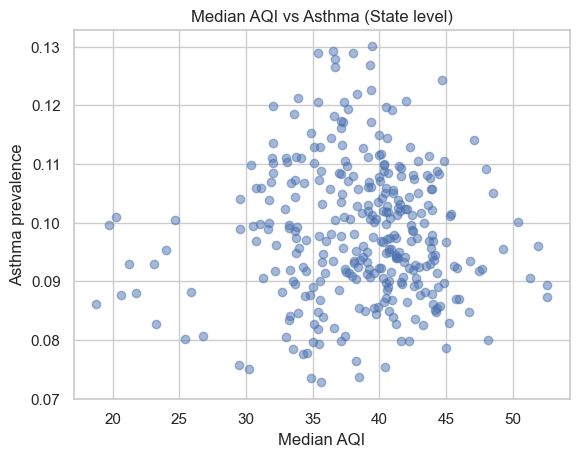

In [65]:
plt.scatter(
    merged_state["Median AQI"],
    merged_state["asthma"],
    alpha=0.5
)

plt.xlabel("Median AQI")
plt.ylabel("Asthma prevalence")
plt.title("Median AQI vs Asthma (State level)")
plt.show()

The points form a cloud with no clear trend, there is no strong upward or downward slope. For the same AQI of around 40, asthma prevalence varies from ~0.08 to ~0.12. It suggestis that air quality alone does not strongly explain variations in asthma prevalence on the state level per year.

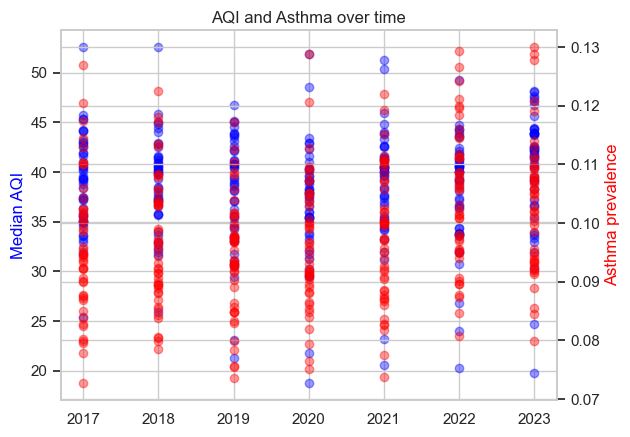

In [61]:
fig, ax1 = plt.subplots()

ax1.scatter(merged_state["Year"], merged_state["Median AQI"], color="blue", alpha=0.4)
ax1.set_ylabel("Median AQI", color="blue")

ax2 = ax1.twinx()
ax2.scatter(merged_state["Year"], merged_state["asthma"], color="red", alpha=0.4)
ax2.set_ylabel("Asthma prevalence", color="red")

plt.title("AQI and Asthma over time")
plt.show()

While AQI values fluctuate slightly over time and vary across states, asthma prevalence remains relatively stable with a wide spread each year. There is no clear parallel movement between the two variables over time, suggesting that changes in air quality do not consistently correspond to changes in asthma prevalence at the state level.

As asthma is triggered by let's create a new variable, that will count the days that the air was detrimental, where AQI > 100, summing up your Unhealthy for Sensitive Groups Days, Unhealthy Days, Very Unhealthy Days, and Hazardous Days.

In [66]:
bad_air_cols = [
    'Unhealthy for Sensitive Groups Days',
    'Unhealthy Days',
    'Very Unhealthy Days',
    'Hazardous Days'
]

merged_state['Bad_Air_Days'] = merged_state[bad_air_cols].sum(axis=1)

merged_state[['State', 'Year', 'asthma', 'Bad_Air_Days']].head()

,State,Year,asthma,Bad_Air_Days
0,Alabama,2017,0.110497,0.888889
1,Alaska,2017,0.080189,7.428571
2,Arizona,2017,0.101053,12.923077
3,Arkansas,2017,0.093685,0.181818
4,California,2017,0.087317,33.377358


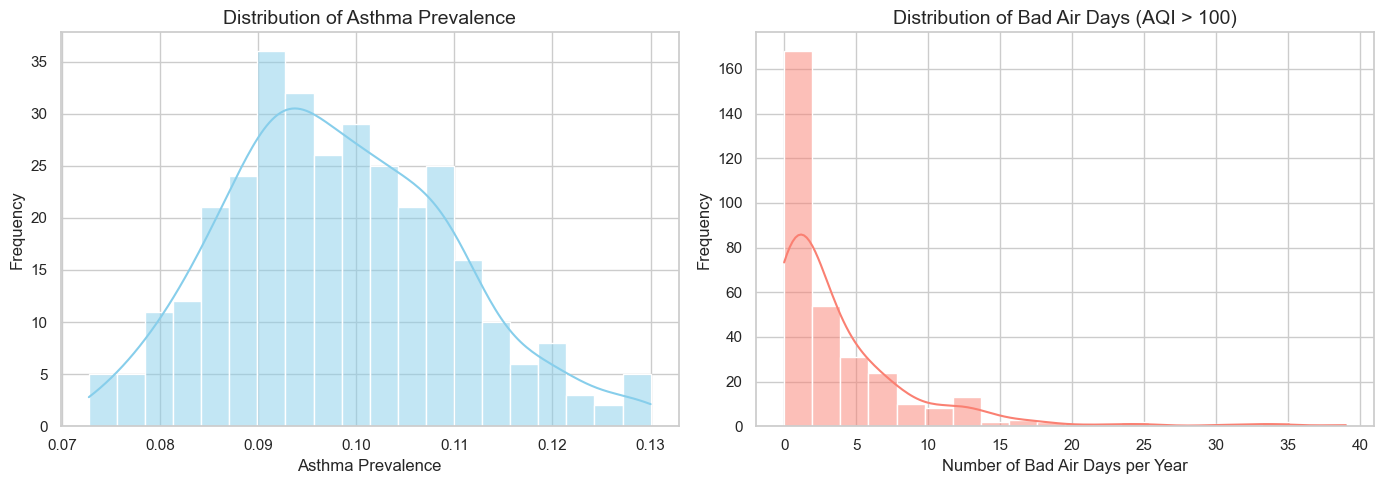

In [67]:
sns.set_theme(style = "whitegrid")

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Plot Asthma Distribution
sns.histplot(merged_state['asthma'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Asthma Prevalence', fontsize=14)
axes[0].set_xlabel('Asthma Prevalence')
axes[0].set_ylabel('Frequency')

# Plot Bad Air Days Distribution
sns.histplot(merged_state['Bad_Air_Days'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Bad Air Days (AQI > 100)', fontsize=14)
axes[1].set_xlabel('Number of Bad Air Days per Year')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The Asthma Prevalence plot shows roughly a normal distribution. Most state-years cluster around the middle, with an asthma prevalence between 9% to 10%. There are fewer states with very low (7%) or very high (13%) rates.

The Bad Air Days distribution is heavily right-skewed. Most of the time, most states experience very few bad air days (between 0 and 5 per year). There are only a few extreme outliers where states suffered from 20, 30, or almost 40 bad air days in a single year.

### Sources:
https://aafa.org/asthma/asthma-triggers-causes/air-pollution-smog-asthma/

https://pmc.ncbi.nlm.nih.gov/articles/PMC7503605/

https://www.nature.com/articles/s41598-025-88807-6

https://www.mdpi.com/2225-1154/13/2/23#B2-climate-13-00023

https://aqs.epa.gov/aqsweb/airdata/download_files.html

https://www.cdc.gov/brfss/annual_data/annual_data.htm

https://www.cdc.gov/brfss/annual_data/2023/pdf/2023-calculated-variables-version4-508.pdf

https://data.cdc.gov/

https://healthdata.gov/State/Asthma-Emergency-Department-Visit-Rates/28nb-65xq/about_data

https://us3.proxysite.com/process.php?d=7aUad2SQtxehj%2FpslPYLothCEh%2Buq24Ou07f0%2FC93NmAV8muq8dzD8DlN3XinTa2D2BXVSxwNF76UOD%2BRTw%3D&b=1
